# Bitcoin Market Sentiment vs Trader Performance Analysis

## Project Overview

This project analyzes the relationship between Bitcoin market sentiment and trader performance using historical trading data from Hyperliquid and the Bitcoin Fear & Greed Index.

The objective is to investigate how different market sentiment conditions influence trading profitability, win rates, capital allocation, and trading behavior.

By combining sentiment data with over 211,000 historical trading records, this analysis aims to uncover actionable insights that can support sentiment-aware trading strategies and improve decision-making in cryptocurrency markets.

---

## Objectives

The key objectives of this analysis are:

1. Examine the relationship between market sentiment and trading profitability.
2. Measure trader success rates under different sentiment conditions.
3. Analyze how capital allocation changes across market environments.
4. Identify behavioral patterns in buying and selling activity.
5. Discover which assets contribute most to overall profitability.
6. Generate data-driven recommendations for improving trading performance.

---

## Datasets Used

### 1. Bitcoin Fear & Greed Index Dataset

Columns:
- Date
- Sentiment Classification
- Sentiment Value

Sentiment Categories:
- Extreme Fear
- Fear
- Neutral
- Greed
- Extreme Greed

### 2. Hyperliquid Historical Trader Dataset

Key Columns:
- Account
- Coin
- Execution Price
- Size USD
- Side
- Closed PnL
- Timestamp

The dataset contains over 211,000 trading records representing trader activity across multiple cryptocurrency assets.

## Methodology

The analysis was conducted using the following workflow:

### 1. Data Preparation

- Loaded Bitcoin Fear & Greed Index data.
- Loaded Hyperliquid historical trading data.
- Converted timestamps into a common date format.
- Merged both datasets using trade date.

### 2. Feature Engineering

The following analytical features were created:

- Market Sentiment Classification
- Win Trade Indicator
- Realized Trade Dataset (Non-Zero PnL Trades)

### 3. Exploratory Data Analysis

The merged dataset was analyzed to evaluate:

- Trading activity
- Profitability
- Win rates
- Position sizing behavior
- Buy/Sell patterns
- Asset-level performance

### 4. Validation Analysis

Since more than 50% of trades reported zero realized PnL, a secondary analysis was performed using only non-zero PnL trades to validate the robustness of profitability findings.

## Data Cleaning and Preparation

The Bitcoin Fear & Greed dataset and Hyperliquid trading dataset were loaded and inspected for structure and consistency.

The following preprocessing steps were performed:

- Converted date fields into a common datetime format.
- Extracted trading dates from timestamps.
- Merged sentiment and trading datasets using the trade date.
- Created a win_trade indicator to identify profitable trades.
- Created a realized trade dataset by removing zero-PnL trades for validation analysis.

The final merged dataset contained 211,224 trading records with associated sentiment classifications.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup successful!")

Setup successful!


In [2]:
fear = pd.read_csv("../data/fear_greed_index.csv")
trades = pd.read_csv("../data/historical_data.csv")

print("Fear & Greed Dataset Shape:", fear.shape)
print("Trader Dataset Shape:", trades.shape)

Fear & Greed Dataset Shape: (2644, 4)
Trader Dataset Shape: (211224, 16)


In [3]:
print("Fear & Greed Columns:")
print(fear.columns)

print("\nTrader Columns:")
print(trades.columns)

Fear & Greed Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='str')

Trader Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')


In [4]:
fear.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [6]:
print("Fear & Greed Date Range")

print("Min Date:", fear['date'].min())
print("Max Date:", fear['date'].max())

Fear & Greed Date Range
Min Date: 2018-02-01
Max Date: 2025-05-02


In [7]:
fear['date'] = pd.to_datetime(fear['date'])

trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

trades['date'] = trades['Timestamp IST'].dt.date
trades['date'] = pd.to_datetime(trades['date'])

print("Date conversion successful!")

Date conversion successful!


In [8]:
print(fear['date'].head())

print("\n")

print(trades['date'].head())


0   2018-02-01
1   2018-02-02
2   2018-02-03
3   2018-02-04
4   2018-02-05
Name: date, dtype: datetime64[us]


0   2024-12-02
1   2024-12-02
2   2024-12-02
3   2024-12-02
4   2024-12-02
Name: date, dtype: datetime64[s]


In [9]:
merged = pd.merge(
    trades,
    fear[['date', 'classification']],
    on='date',
    how='left'
)

print("Merged Shape:", merged.shape)

Merged Shape: (211224, 18)


In [10]:
merged[['date', 'classification']].head()

,date,classification
0,2024-12-02,Extreme Greed
1,2024-12-02,Extreme Greed
2,2024-12-02,Extreme Greed
3,2024-12-02,Extreme Greed
4,2024-12-02,Extreme Greed


In [11]:
merged['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [12]:
merged.groupby('classification')['Closed PnL'].agg(
    ['count', 'mean', 'sum', 'max', 'min']
).round(2)

,count,mean,sum,max,min
classification,,,,,
Extreme Fear,21400,34.54,739110.25,115287.00,-31036.69
Extreme Greed,39992,67.89,2715171.31,44223.45,-10259.47
Fear,61837,54.29,3357155.44,135329.09,-35681.75
Greed,50303,42.74,2150129.27,74530.52,-117990.10
Neutral,37686,34.31,1292920.68,48504.10,-24500.00


In [13]:
merged.groupby('classification')['Size USD'].agg(
    ['count', 'mean', 'median', 'max']
).round(2)

,count,mean,median,max
classification,,,,
Extreme Fear,21400,5349.73,766.15,1120971.60
Extreme Greed,39992,3112.25,500.05,665771.71
Fear,61837,7816.11,735.96,3921430.72
Greed,50303,5736.88,555.00,2227114.71
Neutral,37686,4782.73,547.66,3641180.84


In [14]:
merged['win_trade'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('classification')['win_trade'].mean() * 100

win_rate.sort_values(ascending=False)

classification
Extreme Greed    46.494299
Fear             42.076750
Neutral          39.699093
Greed            38.482794
Extreme Fear     37.060748
Name: win_trade, dtype: float64

In [15]:
pd.crosstab(
    merged['classification'],
    merged['Side']
)

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


In [16]:
coin_pnl = merged.groupby('Coin')['Closed PnL'].sum()

coin_pnl.sort_values(
    ascending=False
).head(10)

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64

In [17]:
merged.groupby('classification')['Closed PnL'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
Extreme Fear,21400.0,34.54,1136.06,-31036.69,0.0,0.0,5.64,115287.00
Extreme Greed,39992.0,67.89,766.83,-10259.47,0.0,0.0,10.03,44223.45
Fear,61837.0,54.29,935.36,-35681.75,0.0,0.0,5.59,135329.09
Greed,50303.0,42.74,1116.03,-117990.10,0.0,0.0,4.94,74530.52
Neutral,37686.0,34.31,517.12,-24500.00,0.0,0.0,4.00,48504.10


In [18]:
merged['Closed PnL'].eq(0).mean() * 100

np.float64(50.57001098360034)

In [19]:
realized = merged[merged['Closed PnL'] != 0]

print(realized.shape)

(104408, 19)


In [20]:
realized.groupby('classification')['Closed PnL'].agg(
    ['count','mean','median','sum']
).round(2)

,count,mean,median,sum
classification,,,,
Extreme Fear,10406,71.03,6.39,739110.25
Extreme Greed,20853,130.21,8.53,2715171.31
Fear,29808,112.63,6.35,3357155.44
Greed,25176,85.40,4.93,2150129.27
Neutral,18159,71.20,4.58,1292920.68


In [21]:
zero_pct = (merged['Closed PnL'] == 0).mean() * 100

print(f"Zero PnL Trades: {zero_pct:.2f}%")

Zero PnL Trades: 50.57%


## Data Quality Findings

Before conducting the main analysis, the dataset was evaluated for potential distortions.

### Key Finding

Approximately **50.57% of all trades recorded zero realized profit or loss**.

This observation is important because zero-PnL trades can significantly influence average profitability calculations.

To ensure robust conclusions:

- Primary analysis was conducted using the full dataset.
- Validation analysis was performed using only non-zero realized trades.

The consistency of results across both analyses strengthens confidence in the findings presented throughout this report.

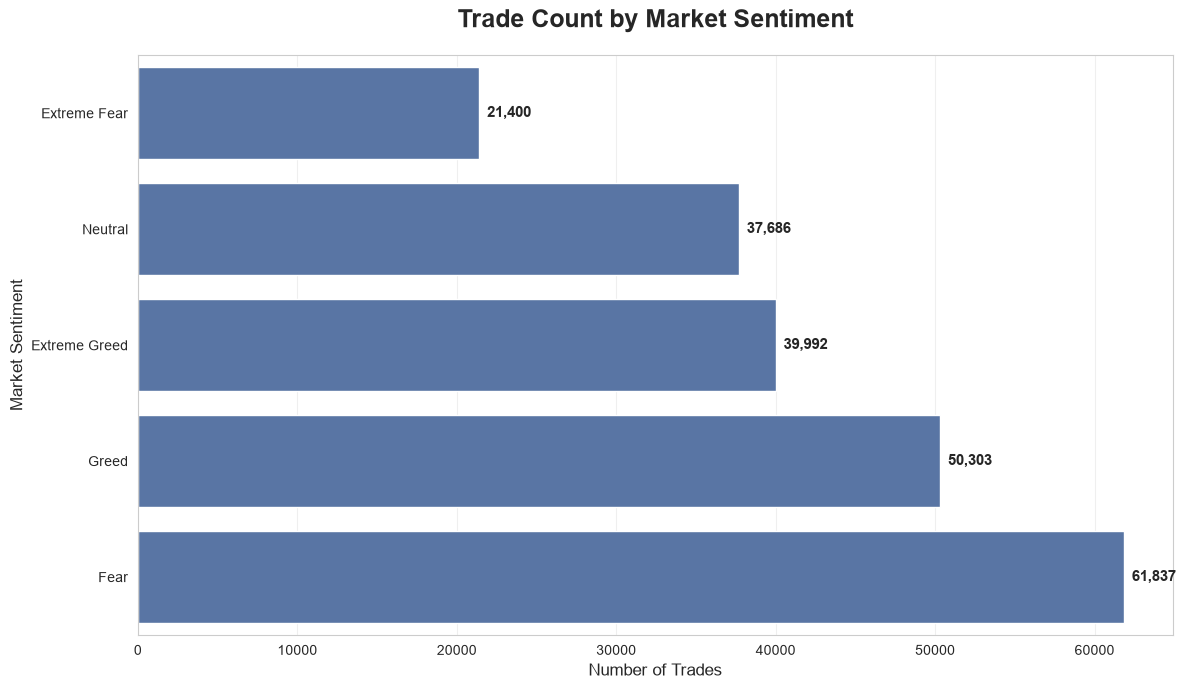

In [22]:
# Chart 1: Trade Count by Market Sentiment

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

sentiment_counts = (
    merged['classification']
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x=sentiment_counts.values,
    y=sentiment_counts.index,
    color='#4C72B0'
)

plt.title(
    'Trade Count by Market Sentiment',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xlabel('Number of Trades', fontsize=12)
plt.ylabel('Market Sentiment', fontsize=12)

for i, value in enumerate(sentiment_counts.values):
    ax.text(
        value + 500,
        i,
        f'{value:,}',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../outputs/chart_01_trade_count_by_sentiment.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Chart 1: Trade Activity by Market Sentiment

This visualization highlights the distribution of trading activity across different market sentiment conditions.

### Key Observations

- Fear recorded the highest trading activity with 61,837 trades.
- Greed followed with 50,303 trades.
- Extreme Fear showed the lowest participation with 21,400 trades.
- More than half of all trading activity occurred during Fear and Greed periods.

### Business Insight

The results suggest that traders remain highly active during emotionally charged market environments. Fear-based markets appear to create a large number of trading opportunities, potentially driven by increased volatility and rapid price movements. This behavior indicates that market pessimism does not discourage participation; instead, it may attract traders seeking profitable opportunities during uncertainty.

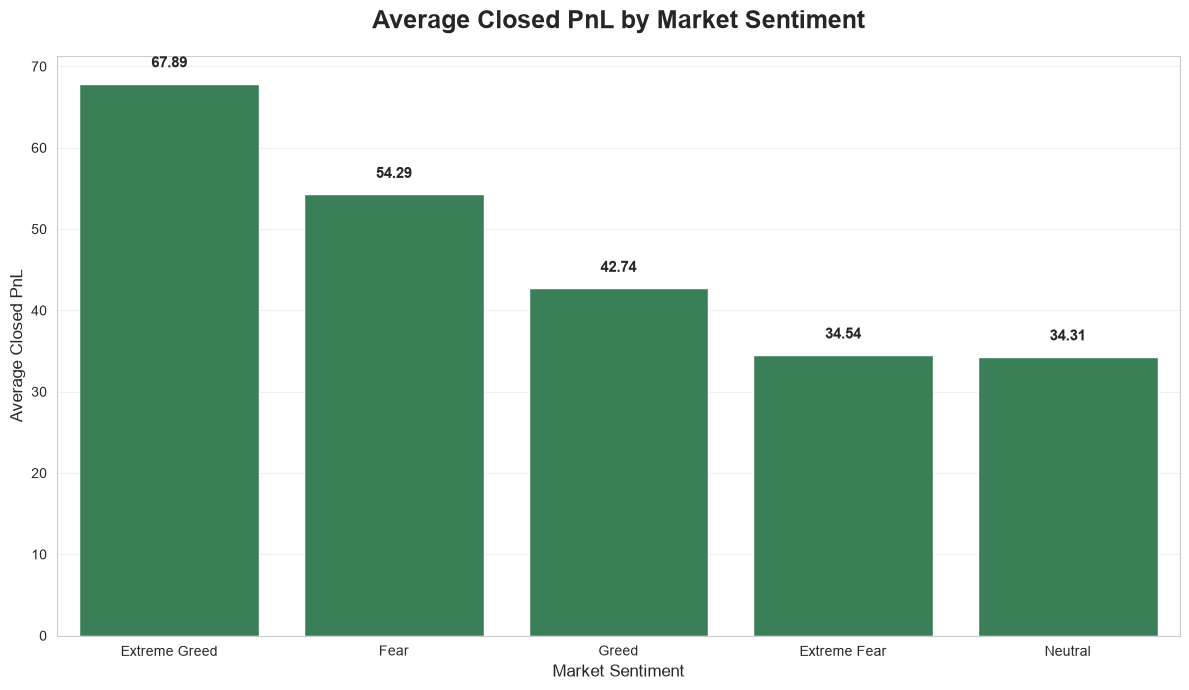

In [23]:
# Chart 2: Average PnL by Market Sentiment

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

avg_pnl = (
    merged.groupby('classification')['Closed PnL']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,7))

ax = sns.barplot(
    x=avg_pnl.index,
    y=avg_pnl.values,
    color='#2E8B57'
)

plt.title(
    'Average Closed PnL by Market Sentiment',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    'Market Sentiment',
    fontsize=12
)

plt.ylabel(
    'Average Closed PnL',
    fontsize=12
)

for i, value in enumerate(avg_pnl.values):
    ax.text(
        i,
        value + 2,
        f'{value:.2f}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../outputs/chart_02_average_pnl_by_sentiment.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Chart 2: Average Profitability by Market Sentiment

This chart compares the average realized profit and loss generated per trade across different market sentiment conditions.

### Key Observations

- Extreme Greed achieved the highest average PnL (67.89).
- Fear ranked second with an average PnL of 54.29.
- Neutral and Extreme Fear produced the lowest average profitability.
- Profitability generally improved as market sentiment became more optimistic.

### Business Insight

The results indicate that strong bullish sentiment is associated with improved trader performance. During Extreme Greed periods, traders may benefit from stronger market momentum, resulting in higher average profitability per trade. However, average values can be influenced by zero-PnL trades and outliers, making further validation necessary.

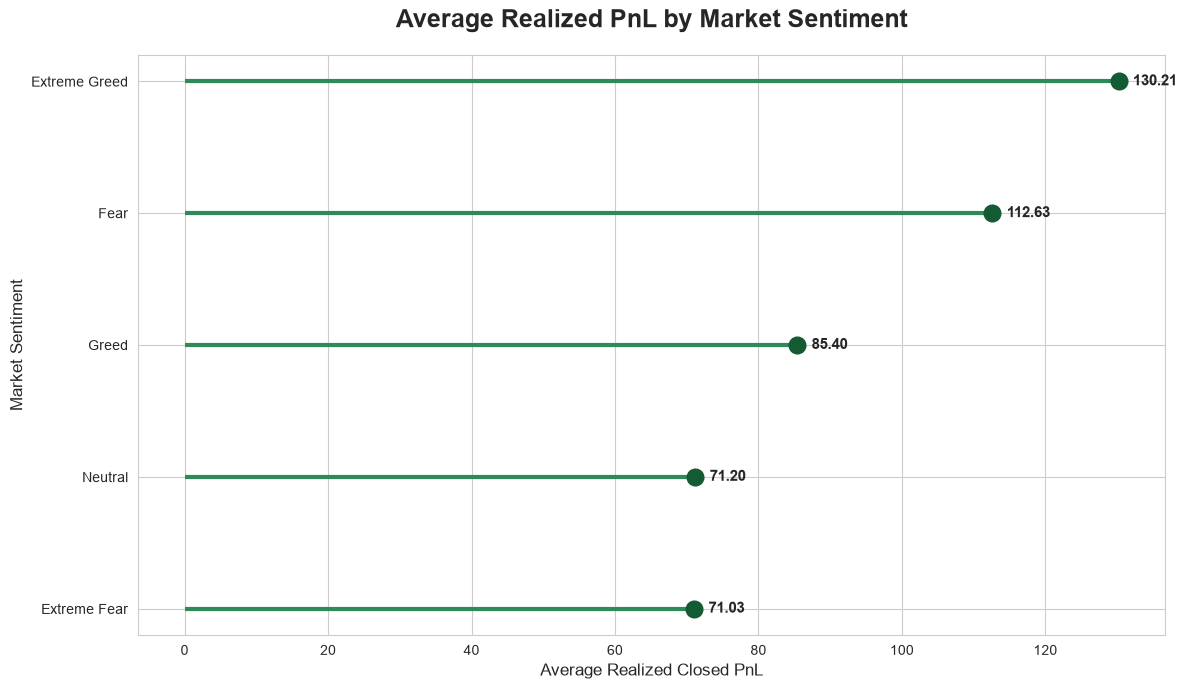

In [24]:
# Chart 3: Average Realized PnL by Market Sentiment

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

realized_avg_pnl = (
    realized.groupby('classification')['Closed PnL']
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12,7))

# Draw stems
plt.hlines(
    y=realized_avg_pnl.index,
    xmin=0,
    xmax=realized_avg_pnl.values,
    color='#2E8B57',
    linewidth=3
)

# Draw dots
plt.plot(
    realized_avg_pnl.values,
    realized_avg_pnl.index,
    "o",
    markersize=12,
    color='#145A32'
)

# Value labels
for i, value in enumerate(realized_avg_pnl.values):
    plt.text(
        value + 2,
        i,
        f'{value:.2f}',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    'Average Realized PnL by Market Sentiment',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    'Average Realized Closed PnL',
    fontsize=12
)

plt.ylabel(
    'Market Sentiment',
    fontsize=12
)

plt.tight_layout()

plt.savefig(
    '../outputs/chart_03_realized_pnl_by_sentiment.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Chart 3: Average Realized Profitability by Market Sentiment

To eliminate the impact of zero-PnL trades, profitability was recalculated using only trades that generated a realized profit or loss.

### Key Observations

- Extreme Greed remained the strongest-performing sentiment category with an average realized PnL of 130.21.
- Fear ranked second with an average realized PnL of 112.63.
- The profitability ranking remained consistent even after removing zero-PnL trades.
- More than 50% of the original dataset consisted of zero-PnL trades, making this validation step critical.

### Business Insight

The persistence of the sentiment ranking after filtering non-realized trades confirms that the observed relationship between market sentiment and trader performance is robust. Extreme Greed continues to provide the most favorable environment for profitable trading, while Fear remains a significant source of trading opportunities due to higher participation and capital deployment.

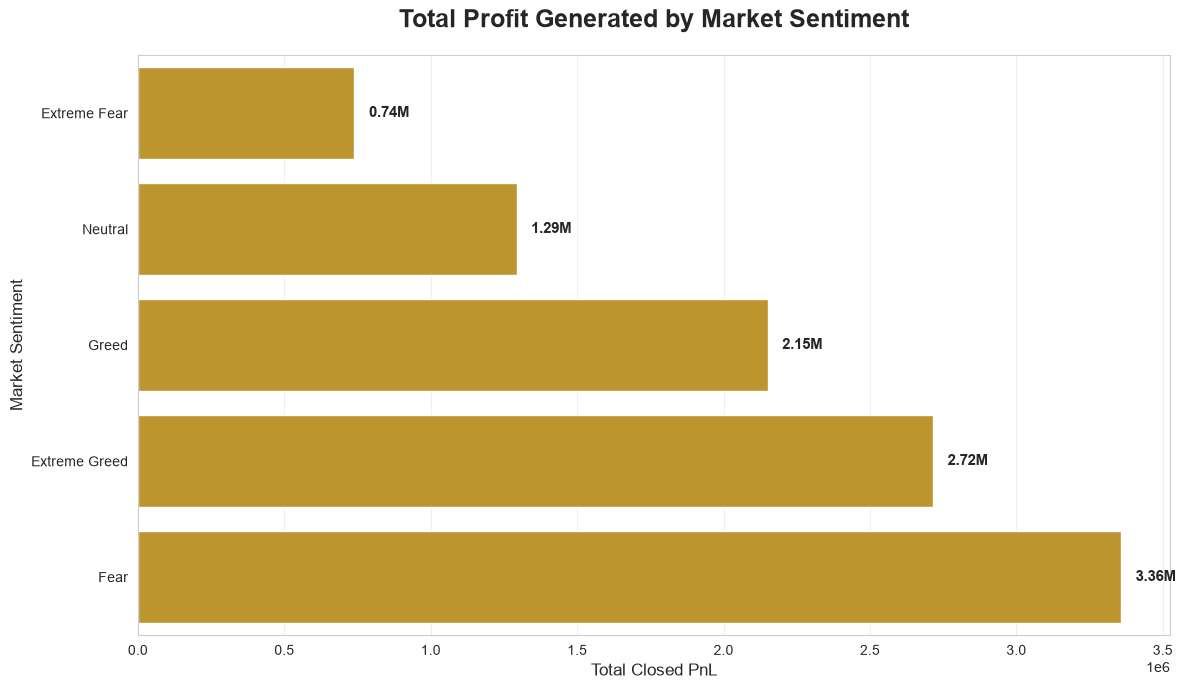

In [25]:
# Chart 4: Total PnL by Market Sentiment

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

total_pnl = (
    merged.groupby('classification')['Closed PnL']
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12,7))

ax = sns.barplot(
    x=total_pnl.values,
    y=total_pnl.index,
    color='#D4A017'
)

plt.title(
    'Total Profit Generated by Market Sentiment',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    'Total Closed PnL',
    fontsize=12
)

plt.ylabel(
    'Market Sentiment',
    fontsize=12
)

for i, value in enumerate(total_pnl.values):
    ax.text(
        value + 50000,
        i,
        f'{value/1000000:.2f}M',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../outputs/chart_04_total_pnl_by_sentiment.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Chart 4: Total Profit Generated by Market Sentiment

This chart measures the cumulative profit generated under each market sentiment condition.

### Key Observations

- Fear generated the highest total profit, exceeding 3.35 million.
- Extreme Greed produced the second-highest total profit despite having fewer trades.
- Extreme Fear generated the lowest aggregate profitability.
- Total profitability is influenced not only by trade performance but also by trading activity and capital allocation.

### Business Insight

While Extreme Greed delivered the highest profitability on a per-trade basis, Fear generated the greatest cumulative profit. This suggests that traders become significantly more active during fearful market conditions, increasing both trading frequency and capital deployment. As a result, Fear-based markets create substantial aggregate profit opportunities despite lower average efficiency compared to Extreme Greed.

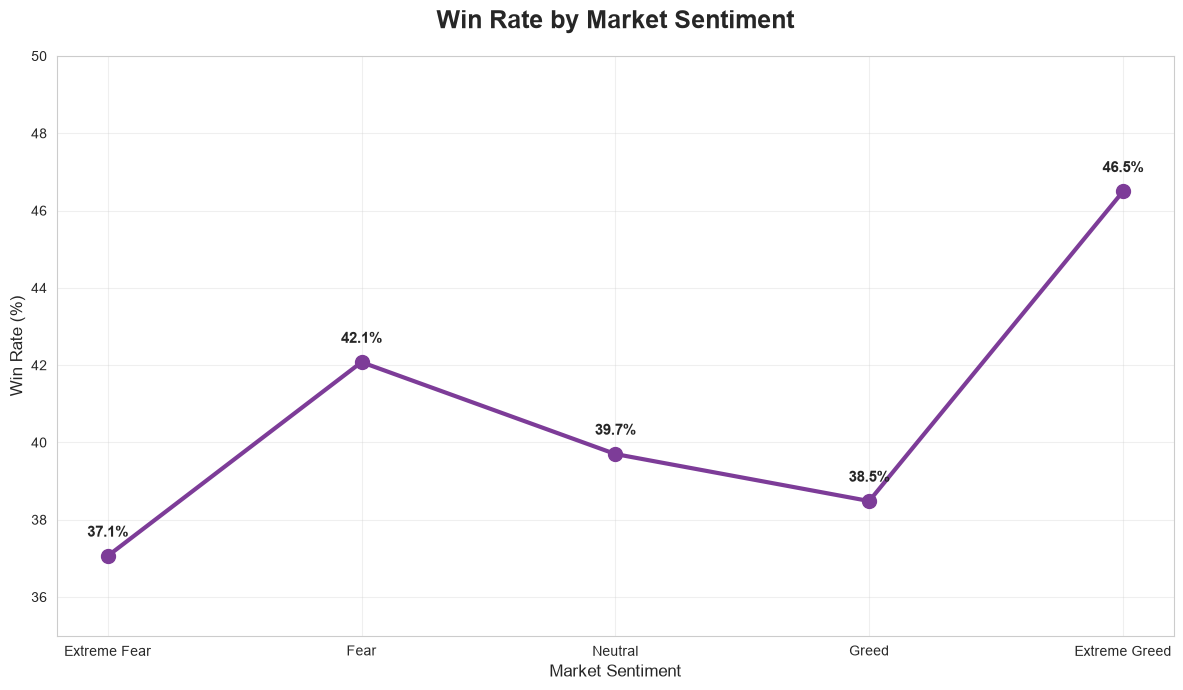

In [26]:
# Chart 5: Win Rate by Market Sentiment

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

win_rate = (
    merged.groupby('classification')['win_trade']
    .mean()
    .mul(100)
)

# Custom order
order = [
    'Extreme Fear',
    'Fear',
    'Neutral',
    'Greed',
    'Extreme Greed'
]

win_rate = win_rate.reindex(order)

plt.figure(figsize=(12,7))

plt.plot(
    win_rate.index,
    win_rate.values,
    marker='o',
    linewidth=3,
    markersize=10,
    color='#7D3C98'
)

# Value labels
for i, value in enumerate(win_rate.values):
    plt.text(
        i,
        value + 0.5,
        f'{value:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    'Win Rate by Market Sentiment',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    'Market Sentiment',
    fontsize=12
)

plt.ylabel(
    'Win Rate (%)',
    fontsize=12
)

plt.ylim(35, 50)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../outputs/chart_05_win_rate_by_sentiment.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Chart 5: Win Rate by Market Sentiment

This chart evaluates the percentage of profitable trades across different market sentiment conditions.

### Key Observations

- Extreme Greed achieved the highest win rate at 46.49%.
- Fear delivered the second-highest win rate at 42.08%.
- Extreme Fear recorded the lowest win rate at 37.06%.
- Win rates generally improved as market sentiment became more optimistic.

### Business Insight

The results indicate that trader success rates are strongly influenced by market sentiment. Bullish market environments appear to provide more favorable trading conditions, increasing the probability of profitable outcomes. In contrast, highly pessimistic market conditions reduce trading effectiveness and increase the likelihood of unsuccessful trades.

### Strategic Interpretation

The combination of the highest average realized PnL and highest win rate during Extreme Greed suggests that strong market momentum not only improves profitability but also increases the consistency of trading outcomes.

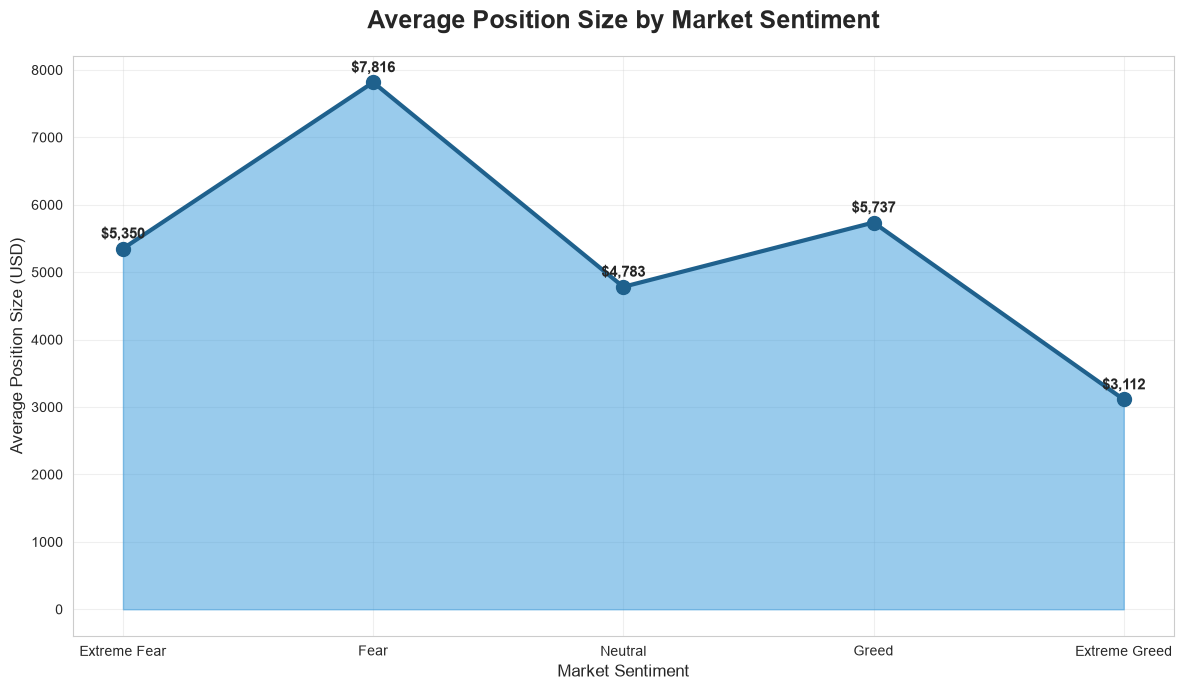

In [27]:
# Chart 6: Average Position Size by Market Sentiment

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

position_size = (
    merged.groupby('classification')['Size USD']
    .mean()
)

order = [
    'Extreme Fear',
    'Fear',
    'Neutral',
    'Greed',
    'Extreme Greed'
]

position_size = position_size.reindex(order)

plt.figure(figsize=(12,7))

plt.fill_between(
    position_size.index,
    position_size.values,
    alpha=0.5,
    color='#3498DB'
)

plt.plot(
    position_size.index,
    position_size.values,
    linewidth=3,
    marker='o',
    markersize=10,
    color='#1F618D'
)

for i, value in enumerate(position_size.values):
    plt.text(
        i,
        value + 150,
        f'${value:,.0f}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    'Average Position Size by Market Sentiment',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    'Market Sentiment',
    fontsize=12
)

plt.ylabel(
    'Average Position Size (USD)',
    fontsize=12
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../outputs/chart_06_position_size_by_sentiment.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Chart 6: Average Position Size by Market Sentiment

This chart examines how trader capital allocation changes across different market sentiment conditions.

### Key Observations

- Fear recorded the highest average position size at approximately $7,816.
- Greed followed with an average position size of approximately $5,737.
- Extreme Greed showed the smallest average position size despite producing the highest profitability.
- Capital allocation patterns do not perfectly align with profitability patterns.

### Business Insight

Traders appear to commit significantly more capital during Fear conditions, suggesting that pessimistic markets are perceived as attractive entry opportunities. Interestingly, Extreme Greed generated the highest profitability while requiring smaller average position sizes, indicating that market momentum may improve trading efficiency without requiring greater risk exposure.

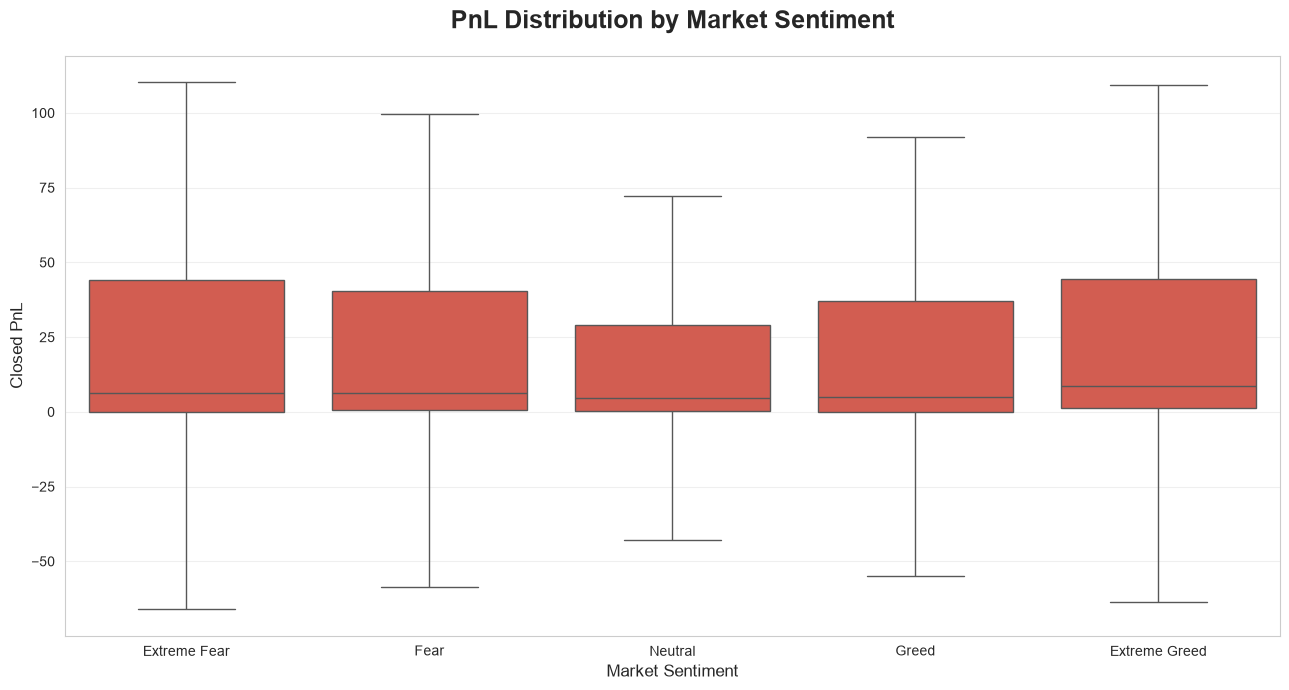

In [28]:
# Chart 7: PnL Distribution by Market Sentiment

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

order = [
    'Extreme Fear',
    'Fear',
    'Neutral',
    'Greed',
    'Extreme Greed'
]

plt.figure(figsize=(13,7))

sns.boxplot(
    data=realized,
    x='classification',
    y='Closed PnL',
    order=order,
    color='#E74C3C',
    showfliers=False
)

plt.title(
    'PnL Distribution by Market Sentiment',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    'Market Sentiment',
    fontsize=12
)

plt.ylabel(
    'Closed PnL',
    fontsize=12
)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../outputs/chart_07_pnl_distribution_boxplot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Chart 7: Profit Distribution by Market Sentiment

This boxplot visualizes the distribution of realized profits across different sentiment categories.

### Key Observations

- Profitability distributions vary significantly across sentiment conditions.
- Extreme Greed exhibits a higher central tendency compared to other sentiment states.
- Fear and Greed display wider distributions, indicating greater variability in trading outcomes.
- Large outliers are present throughout the dataset, confirming that a small number of trades contribute disproportionately to overall profitability.

### Business Insight

The analysis reveals that market sentiment influences not only average profitability but also the consistency and variability of trading outcomes. Fear-driven markets create larger profit opportunities but are associated with greater dispersion of results, whereas Extreme Greed offers a more favorable balance between profitability and consistency.

<Figure size 1200x700 with 0 Axes>

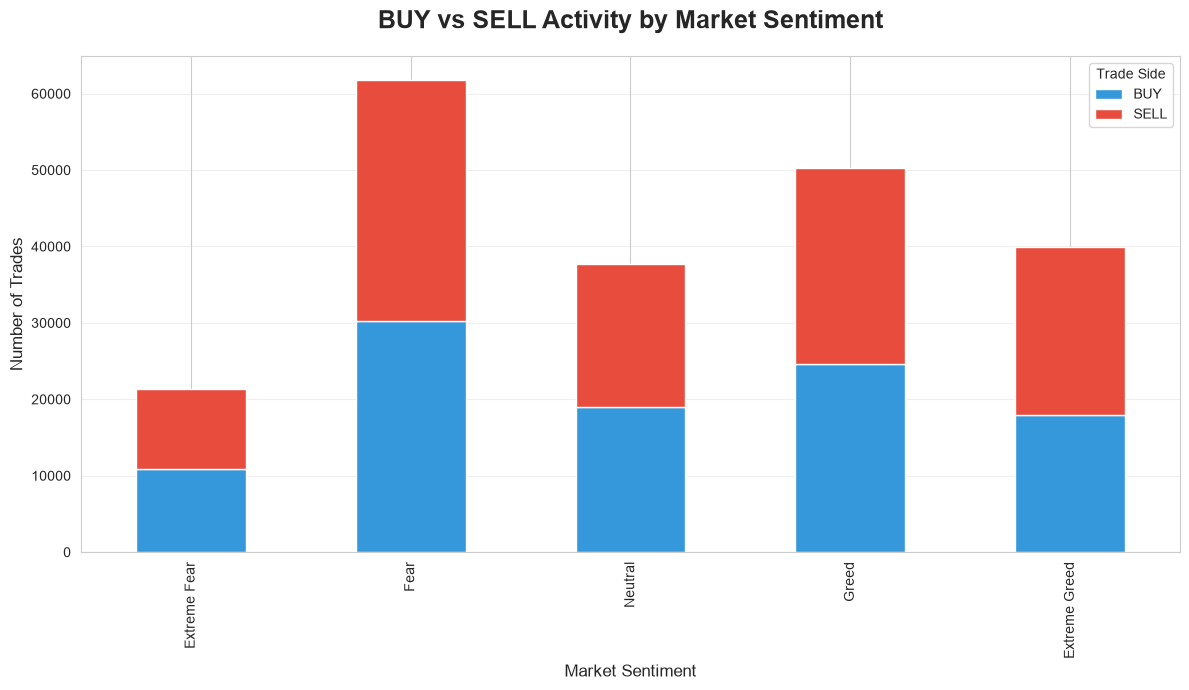

In [29]:
# Chart 8: BUY vs SELL Activity by Market Sentiment

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")

side_counts = pd.crosstab(
    merged['classification'],
    merged['Side']
)

order = [
    'Extreme Fear',
    'Fear',
    'Neutral',
    'Greed',
    'Extreme Greed'
]

side_counts = side_counts.reindex(order)

plt.figure(figsize=(12,7))

side_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(12,7),
    color=['#3498DB', '#E74C3C']
)

plt.title(
    'BUY vs SELL Activity by Market Sentiment',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    'Market Sentiment',
    fontsize=12
)

plt.ylabel(
    'Number of Trades',
    fontsize=12
)

plt.legend(
    title='Trade Side'
)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../outputs/chart_08_buy_vs_sell_behavior.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Chart 8: BUY vs SELL Activity by Market Sentiment

This chart compares buying and selling activity across different market sentiment conditions.

### Key Observations

- Selling activity exceeded buying activity during Fear, Greed, and Extreme Greed periods.
- Extreme Greed showed the strongest sell-side dominance.
- Neutral markets exhibited a nearly balanced distribution between buying and selling activity.
- Extreme Fear displayed the most balanced trading behavior.

### Business Insight

The dominance of sell-side activity during Greed and Extreme Greed conditions suggests that traders may be actively realizing profits during bullish market phases. Conversely, Fear conditions maintain strong buy-side participation, indicating that many traders view market weakness as a potential buying opportunity. This behavior aligns with the classic market principle of "buy fear, sell greed."

### Behavioral Interpretation

The gradual increase in sell-side activity as sentiment shifts from Fear to Extreme Greed may indicate profit-taking behavior. Traders appear more willing to exit positions during euphoric market conditions while maintaining stronger accumulation behavior during fearful periods.

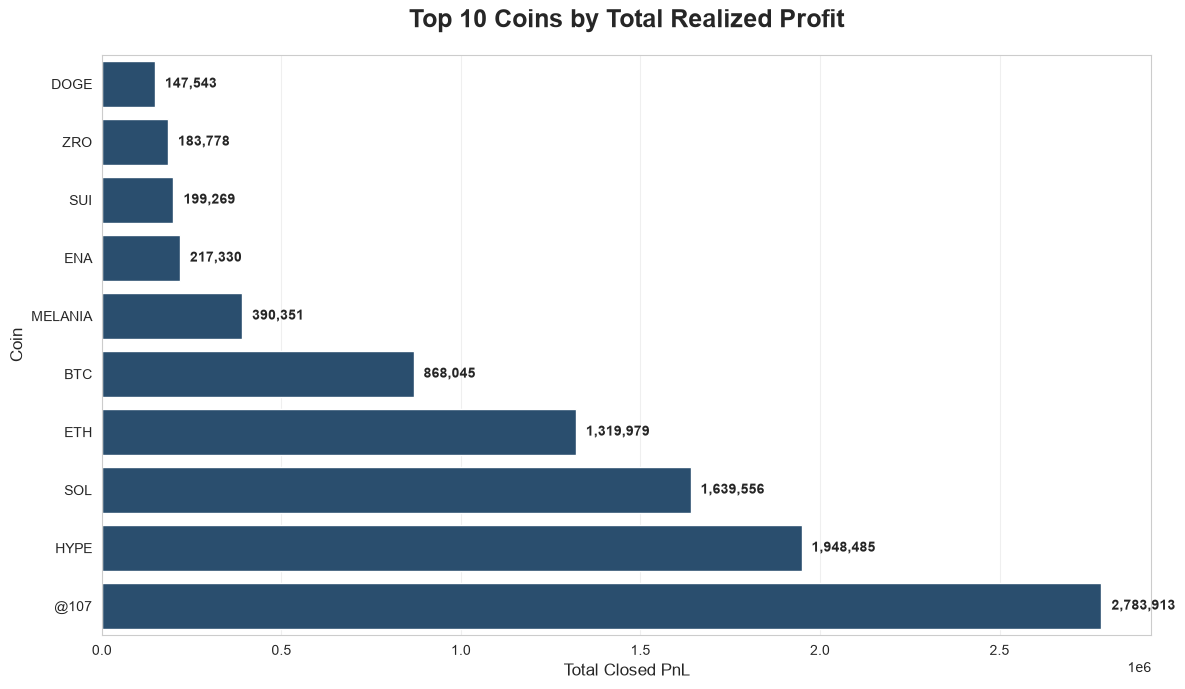

In [30]:
# Chart 9: Top 10 Coins by Total Profit

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

top_coins = (
    merged.groupby('Coin')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values(ascending=True)
)

plt.figure(figsize=(12,7))

ax = sns.barplot(
    x=top_coins.values,
    y=top_coins.index,
    color='#1F4E79'
)

plt.title(
    'Top 10 Coins by Total Realized Profit',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    'Total Closed PnL',
    fontsize=12
)

plt.ylabel(
    'Coin',
    fontsize=12
)

for i, value in enumerate(top_coins.values):
    ax.text(
        value + (top_coins.max()*0.01),
        i,
        f'{value:,.0f}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../outputs/chart_09_top_10_coins_profit.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Chart 9: Top 10 Assets by Total Profitability

This chart ranks the ten highest-performing trading instruments based on cumulative realized profit (Closed PnL).

### Key Observations

* The instrument labeled **@107** generated the highest cumulative profit among all traded assets.
* Among the major cryptocurrency assets, **HYPE, SOL, ETH, and BTC** were the strongest contributors to overall profitability.
* Profit generation was concentrated within a relatively small group of assets, with the top-ranked instruments accounting for a substantial share of total returns.
* The remaining assets contributed comparatively lower profits, indicating an uneven distribution of trading opportunities across the market.

### Business Insight

The results suggest that profitability was not evenly distributed across all traded instruments. Instead, a relatively small subset of assets generated the majority of trading profits. This highlights the importance of asset selection and suggests that successful traders were able to identify and capitalize on high-performing market opportunities.

### Portfolio Concentration Insight

A significant proportion of total profitability originated from the top-performing assets. This concentration indicates that trader performance may have been driven more by effective participation in a limited number of high-performing instruments than by broad market exposure.

### Analytical Note

The instrument **@107** exhibited exceptionally high profitability relative to other assets. As its underlying nature could not be verified from the available dataset, it has been retained in the analysis as reported by the source data, and related findings should be interpreted with appropriate caution.


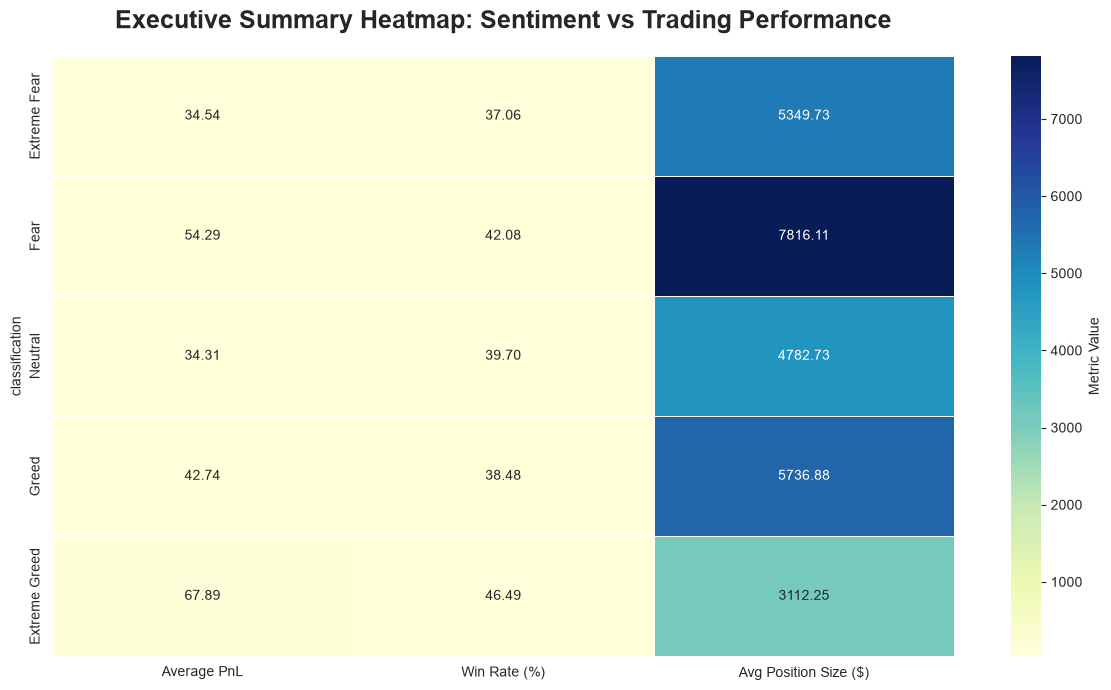

In [31]:
# Chart 10: Executive Summary Heatmap

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("white")

heatmap_data = pd.DataFrame({
    'Average PnL': merged.groupby('classification')['Closed PnL'].mean(),
    'Win Rate (%)': merged.groupby('classification')['win_trade'].mean() * 100,
    'Avg Position Size ($)': merged.groupby('classification')['Size USD'].mean()
})

order = [
    'Extreme Fear',
    'Fear',
    'Neutral',
    'Greed',
    'Extreme Greed'
]

heatmap_data = heatmap_data.reindex(order)

plt.figure(figsize=(12,7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Metric Value'}
)

plt.title(
    'Executive Summary Heatmap: Sentiment vs Trading Performance',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.tight_layout()

plt.savefig(
    '../outputs/chart_10_executive_summary_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Chart 10: Executive Summary Heatmap

This heatmap consolidates the key trading performance metrics across all market sentiment conditions.

### Metrics Included

- Average Profitability (Average PnL)
- Trading Success Rate (Win Rate)
- Average Capital Allocation (Position Size)

### Key Observations

- Extreme Greed achieved the highest Average PnL and Win Rate.
- Fear exhibited the largest average position sizes and the highest cumulative profitability.
- Extreme Fear consistently produced the weakest performance metrics.
- Different sentiment states influence trader behavior, profitability, and risk allocation in distinct ways.

### Business Insight

The heatmap highlights a clear relationship between market sentiment and trading performance. While Extreme Greed provides the most favorable environment for profitable and consistent trading outcomes, Fear encourages greater market participation and capital deployment. These findings suggest that sentiment-aware trading strategies may improve both profitability and risk-adjusted decision-making.


# Executive Summary

This study examined the relationship between Bitcoin market sentiment and trader performance by integrating the Bitcoin Fear & Greed Index with over 211,000 historical trading records from Hyperliquid.

The analysis revealed a strong connection between market sentiment and trading outcomes. Traders performed most efficiently during periods of Extreme Greed, achieving the highest average profitability and win rates. In contrast, Fear-driven markets generated the highest cumulative profits due to increased trading activity and larger average position sizes.

A significant finding was that approximately 50.57% of trades recorded zero realized profit or loss. To ensure analytical robustness, a validation analysis was conducted using only non-zero PnL trades. The core profitability patterns remained consistent, strengthening confidence in the results.

Behavioral analysis further showed that trader activity changes with market sentiment. Fear conditions encouraged larger capital deployment, while Extreme Greed conditions exhibited stronger sell-side activity, suggesting profit-taking behavior during bullish market phases.

Overall, the findings indicate that market sentiment is a valuable indicator of trading performance, trader behavior, and capital allocation decisions.

# Final Key Findings

### 1. Extreme Greed Is The Most Efficient Trading Environment

Extreme Greed recorded the highest Average PnL (67.89), highest Realized PnL (130.21), and highest Win Rate (46.49%), indicating that strong bullish momentum improves both profitability and trading consistency.

### 2. Fear Generates The Largest Total Profit

Despite lower efficiency metrics, Fear produced the highest cumulative profit (3.36M) due to significantly higher trading activity and larger average position sizes.

### 3. Capital Allocation Peaks During Fear

Traders deployed the largest average position sizes during Fear periods, suggesting that market pessimism is often perceived as an attractive buying opportunity.

### 4. Trading Activity Is Highly Sentiment Driven

More than half of all trades occurred during Fear and Greed periods, demonstrating that emotional market conditions stimulate trading participation.

### 5. Profitability Is Concentrated In A Small Number Of Assets

A relatively small number of instruments generated the majority of total realized profits. HYPE, SOL, ETH, and BTC were among the most significant contributors, while the instrument labeled **@107** emerged as a notable outlier with exceptionally high profitability and should be interpreted cautiously.


### 6. Zero-PnL Trades Represent A Significant Portion Of The Dataset

Approximately 50.57% of trades recorded zero realized profit or loss. Additional validation confirmed that the primary findings remained consistent after removing these trades.

# Recommendations

Based on the findings of this analysis, the following recommendations are proposed:

### 1. Incorporate Sentiment Into Trading Strategies

Market sentiment demonstrated a measurable impact on profitability and win rates. Traders and trading systems should consider incorporating sentiment indicators as part of their decision-making framework.

### 2. Monitor Extreme Greed Conditions For High-Probability Opportunities

Extreme Greed consistently delivered the highest average profitability and win rates. Momentum-based trading strategies may perform particularly well during strongly bullish market environments.

### 3. Leverage Fear Periods For Capital Deployment

Fear conditions generated the highest total profitability and largest average position sizes. These periods may provide attractive opportunities for accumulation and value-based trading strategies.

### 4. Implement Risk Controls During Extreme Fear

Extreme Fear recorded the weakest trading performance metrics and lowest win rates. Enhanced risk management measures should be considered during highly pessimistic market conditions.

### 5. Focus On High-Performing Assets

Profitability was concentrated among a relatively small group of assets, including @107, HYPE, SOL, ETH, and BTC. Asset selection remains a critical factor influencing overall trading performance.

### 6. Track Realized Performance Metrics

Given the large proportion of zero-PnL trades in the dataset, performance evaluation should emphasize realized profitability metrics rather than relying solely on overall averages.

# Limitations

While the analysis identifies strong relationships between market sentiment and trader performance, several limitations should be noted:

- The study measures correlation rather than causation.
- Trader-specific characteristics were not analyzed separately.
- Market conditions beyond sentiment (volatility, liquidity, macroeconomic events) were not incorporated.
- The analysis is based on historical data and may not fully predict future market behavior.

Future work could incorporate additional market indicators and trader segmentation techniques to improve predictive power.

# Conclusion

This analysis successfully explored the relationship between Bitcoin market sentiment and trader performance using a combined dataset of market sentiment indicators and historical trading activity.

The results demonstrate that market sentiment significantly influences trading profitability, win rates, position sizing behavior, and trading activity. Extreme Greed emerged as the most favorable trading environment in terms of efficiency and consistency, while Fear conditions generated the highest aggregate profits through increased participation and capital allocation.

The study also highlighted the importance of validating findings using realized-profit trades, particularly in datasets containing a large proportion of zero-PnL observations. The consistency of results across validation analyses strengthens the reliability of the conclusions.

Overall, the findings suggest that sentiment-aware trading approaches have the potential to improve decision-making, enhance profitability, and support more effective risk management in cryptocurrency markets. Future research could extend this analysis by incorporating additional market indicators, trader segmentation, and time-series forecasting techniques.